# Customer Churn Analysis

## 03. Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned customer dataset and identify patterns associated with customer churn.

The analysis will focus on:

- Overall churn distribution.
- Customer tenure.
- Monthly and total charges.
- Contract type.
- Payment method.
- Internet service.
- Support services.
- Demographic characteristics.
- Customer segments with higher churn rates.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = Path(
    "../data/processed/telco_customer_churn_clean.csv"
)

df = pd.read_csv(data_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 7,043
Columns: 21


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   str    
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

In [4]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Missing values:", df.isna().sum().sum())
print("Duplicated rows:", df.duplicated().sum())
print("Unique customer IDs:", df["customer_id"].nunique())

Missing values: 0
Duplicated rows: 0
Unique customer IDs: 7043


In [6]:
df["churn"].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["churn"].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:
# This function calculates the churn count and percentage, and returns a summary DataFrame.
churn_count = df["churn"].value_counts()

# The function calculates the churn percentage by normalizing the value counts of the "churn" column, multiplying by 100 to get a percentage, and rounding to two decimal places.
churn_percentage = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# and creates a summary DataFrame with the churn count and percentage.
churn_summary = pd.DataFrame({
    "customers": churn_count,
    "percentage": churn_percentage
})

churn_summary

,customers,percentage
churn,,
No,5174,73.46
Yes,1869,26.54


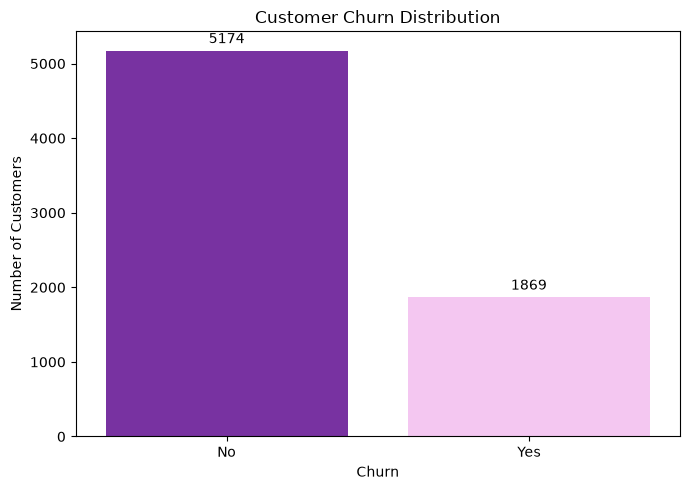

In [9]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="churn",
    hue="churn",
    palette=["#7d1fb4", "#fcbff8"],
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [10]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

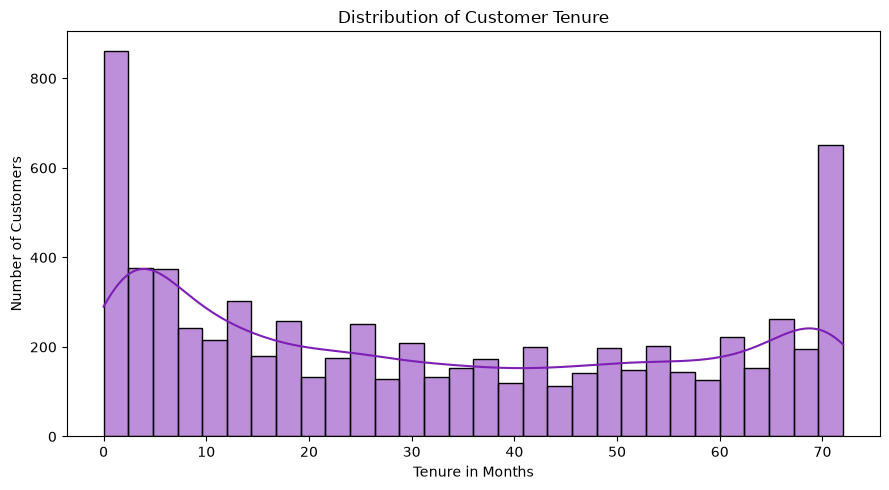

In [11]:
plt.figure(figsize=(9, 5))

# this histplot with sns
sns.histplot(
    # take the data from the df DataFrame.
    data=df,
    x="tenure",
    # set the number of bins to 30.
    bins=30,
    kde=True,
    color="#7d1fb4"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

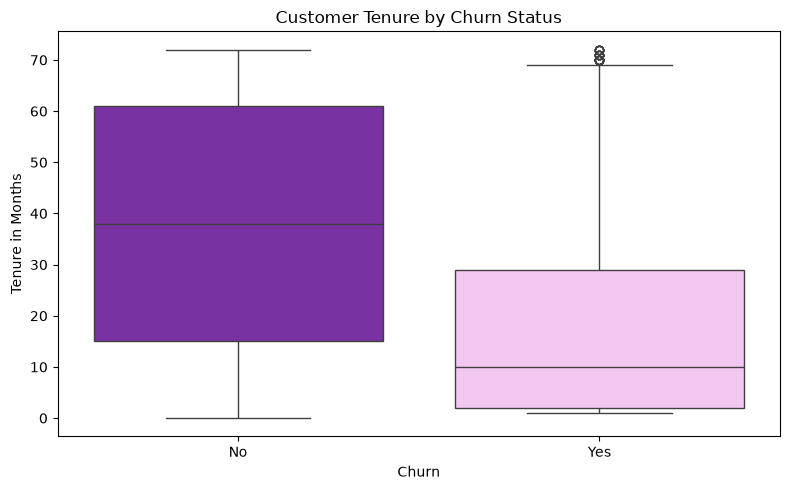

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="tenure",
    hue="churn",
    palette=["#7d1fb4", "#fcbff8"],
    legend=False
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")

plt.tight_layout()
plt.show()

In [13]:
df.groupby("churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


## Numerical Variables

This section explores the three numerical variables contained in the dataset.

- tenure
- monthly_charges
- total_charges

The objective is to understand their distribution and determine whether they are associated with customer churn.

In [14]:
numerical_columns = [
    "tenure",
    "monthly_charges",
    "total_charges"
]

In [15]:
# describe calculate describe stadistics and T method make the transpose.
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
total_charges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


## Customer Tenure

Customer tenure represents the number of months that a customer has remained with the company.

Understanding its distribution helps determine whether the customer base is mainly composed of new customers, long-term customers, or a combination of both.

In [16]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

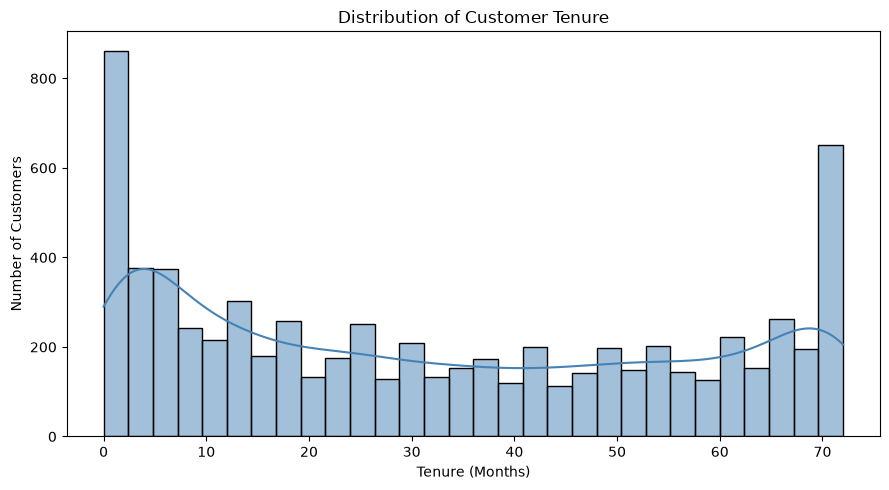

In [17]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

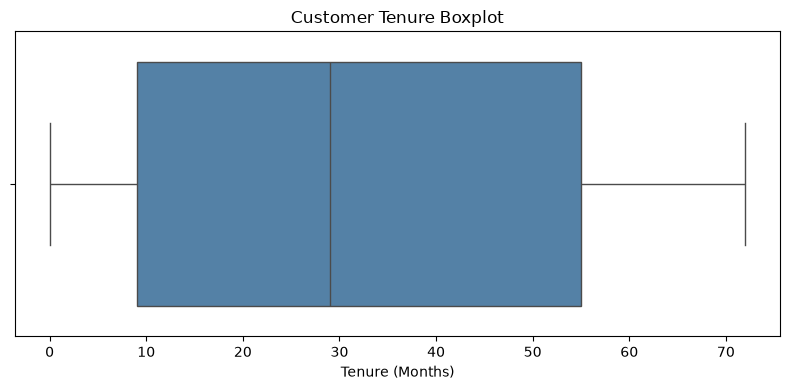

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="tenure",
    color="steelblue"
)

plt.title("Customer Tenure Boxplot")
plt.xlabel("Tenure (Months)")

plt.tight_layout()
plt.show()

### Observations

- Customer tenure ranges from 0 to 72 months.
- The distribution shows a large number of relatively new customers and another concentration of long-term customers.
- The median tenure is lower than the maximum possible value, indicating that many customers have not remained with the company for several years.
- Since tenure measures customer loyalty, it is expected to be an important predictor of churn in the machine learning stage.

In [19]:
df["monthly_charges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

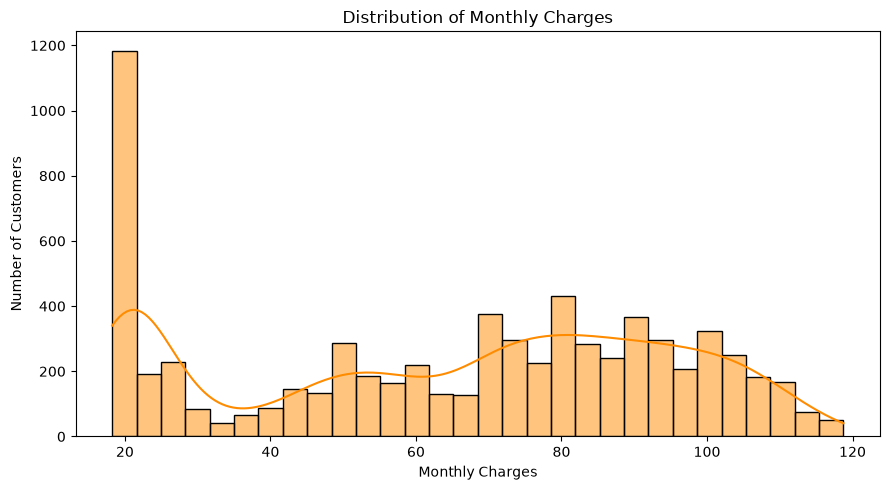

In [20]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="monthly_charges",
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

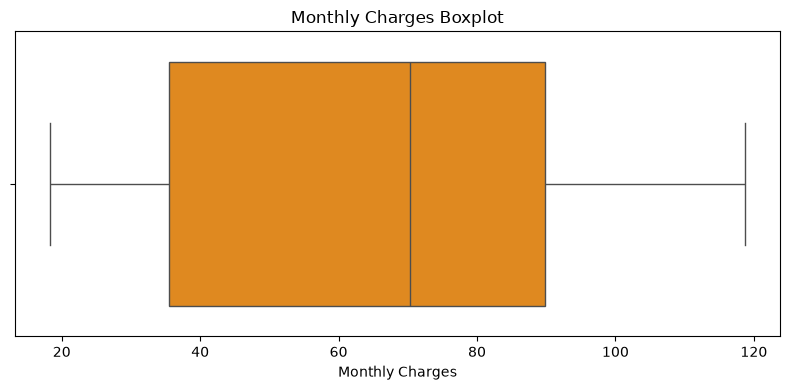

In [21]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="monthly_charges",
    color="darkorange"
)

plt.title("Monthly Charges Boxplot")
plt.xlabel("Monthly Charges")

plt.tight_layout()
plt.show()

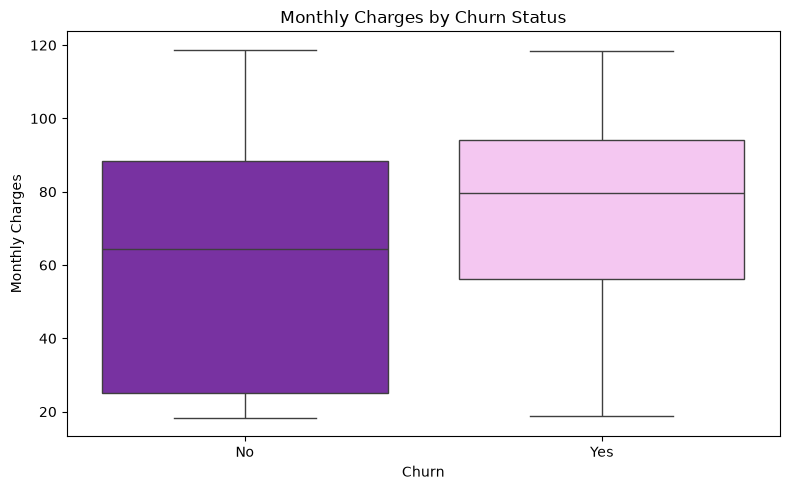

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges",
    hue="churn",
    palette=["#7d1fb4", "#fcbff8"],
    legend=False
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [23]:
df.groupby("churn")["monthly_charges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


### Observations

- Monthly charges range from approximately 18 to 119.
- Customers who churn tend to have higher monthly charges.
- The distribution suggests different pricing tiers among customers.
- Monthly charges may be an important predictor of churn and should be included in the machine learning model.

## Total Charges

Total charges represent the cumulative amount paid by each customer since joining the company.

Because this variable depends on both monthly charges and customer tenure, it provides additional insight into long-term customer value.

In [24]:
df["total_charges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: total_charges, dtype: float64

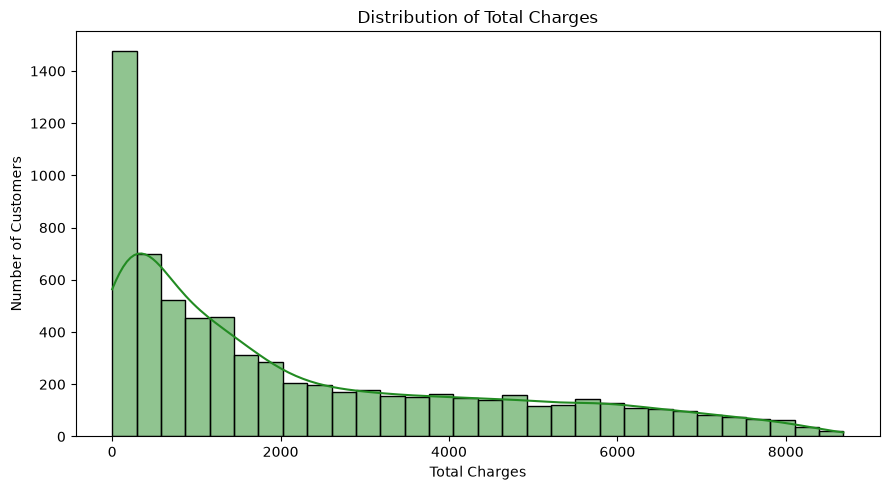

In [25]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="total_charges",
    bins=30,
    kde=True,
    color="forestgreen"
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

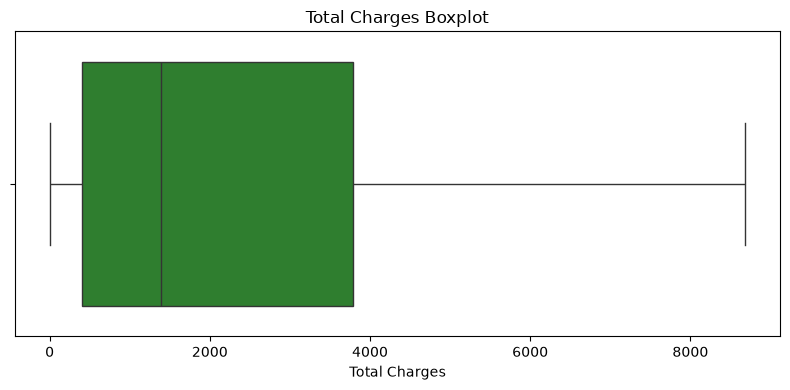

In [26]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="total_charges",
    color="forestgreen"
)

plt.title("Total Charges Boxplot")
plt.xlabel("Total Charges")

plt.tight_layout()
plt.show()

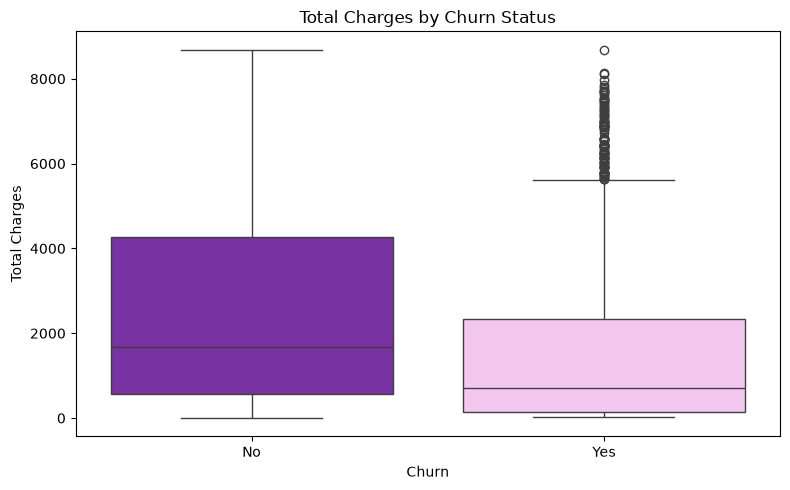

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="total_charges",
    hue="churn",
    palette=["#7d1fb4", "#fcbff8"],
    legend=False
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

In [28]:
df.groupby("churn")["total_charges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
churn,,,,,
No,5174,2549.91,1679.52,0.00,8672.45
Yes,1869,1531.80,703.55,18.85,8684.80


### Observations

- Total charges increase as customers remain with the company longer.
- The distribution is positively skewed, with many customers having relatively low cumulative charges and a smaller group with very high totals.
- Customers with higher total charges generally represent long-term relationships with the company.
- Total charges are expected to complement tenure as an important feature in churn prediction.

In [29]:
categorical_features = [
    "contract",
    "internet_service",
    "payment_method",
    "tech_support",
    "online_security",
    "online_backup",
    "device_protection",
    "streaming_tv",
    "streaming_movies",
    "paperless_billing",
    "partner",
    "dependents",
    "senior_citizen"
]

In [30]:
def analyze_categorical_feature(df, feature):

    print("=" * 70)
    print(feature.upper())
    print("=" * 70)

    display(
        df[feature]
        .value_counts()
        .to_frame("Customers")
    )

    display(
        (
            pd.crosstab(
                df[feature],
                df["churn"],
                normalize="index"
            ) * 100
        ).round(2)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )

    sns.countplot(
        data=df,
        y=feature,
        hue=feature,
        legend=False,
        palette="viridis",
        ax=axes[0]
    )

    axes[0].set_title(f"{feature.replace('_',' ').title()} Distribution")

    churn_table = (
        pd.crosstab(
            df[feature],
            df["churn"],
            normalize="index"
        )*100
    )

    churn_table.plot(
        kind="bar",
        stacked=True,
        color=["#D0FF8A","#84C7F1"],
        ax=axes[1]
    )

    axes[1].set_title(
        f"Churn Rate by {feature.replace('_',' ').title()}"
    )

    plt.tight_layout()

    plt.show()

CONTRACT


,Customers
contract,
Month-to-month,3875
Two year,1695
One year,1473


churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


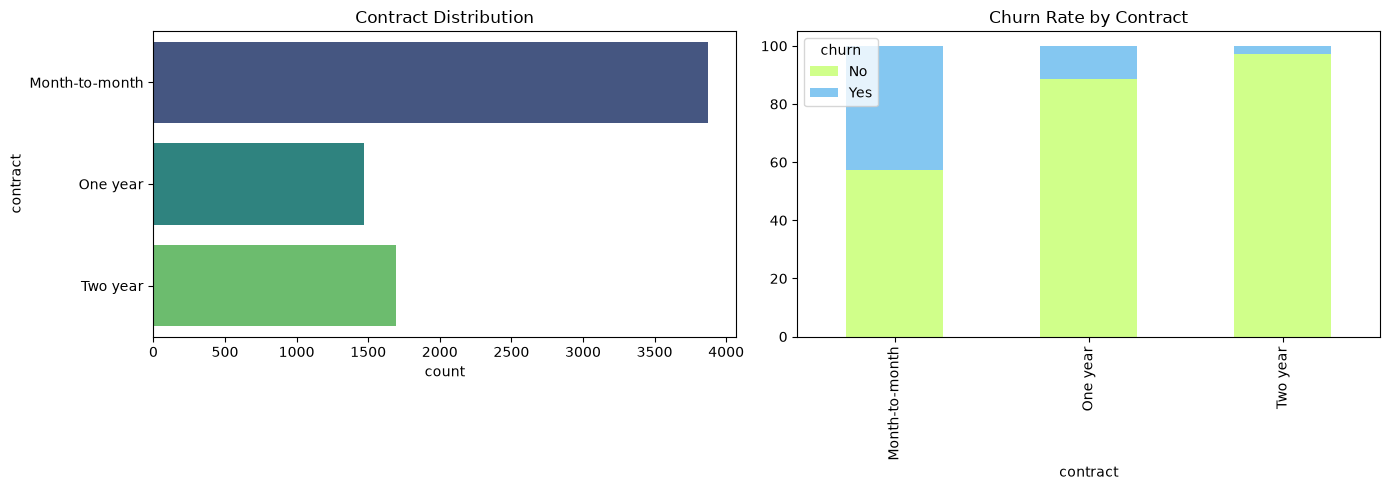

INTERNET_SERVICE


,Customers
internet_service,
Fiber optic,3096
DSL,2421
No,1526


churn,No,Yes
internet_service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


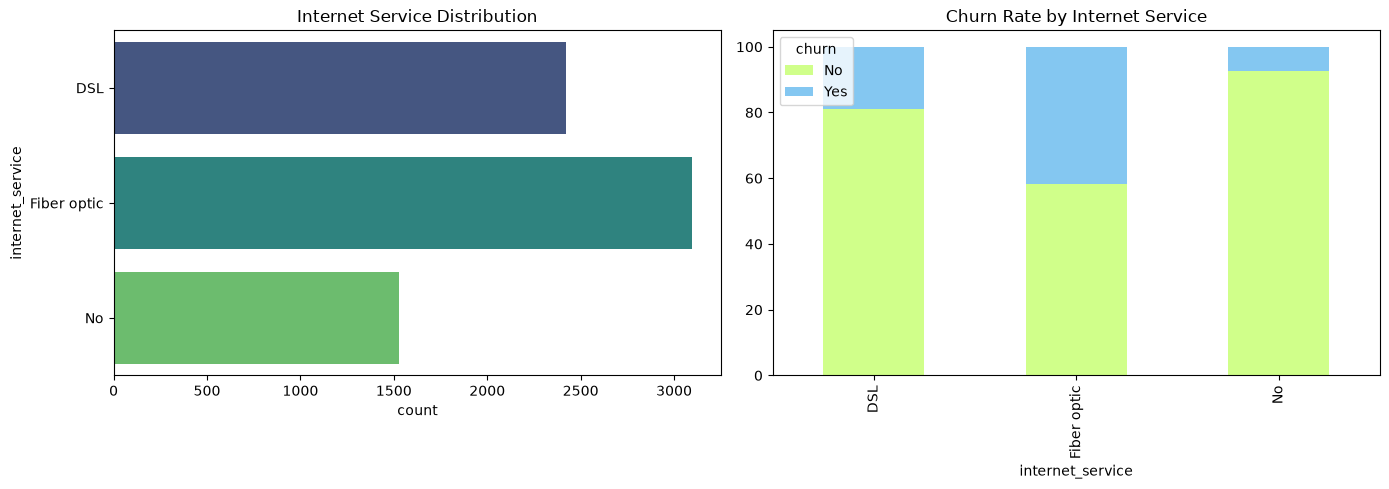

PAYMENT_METHOD


,Customers
payment_method,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


churn,No,Yes
payment_method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


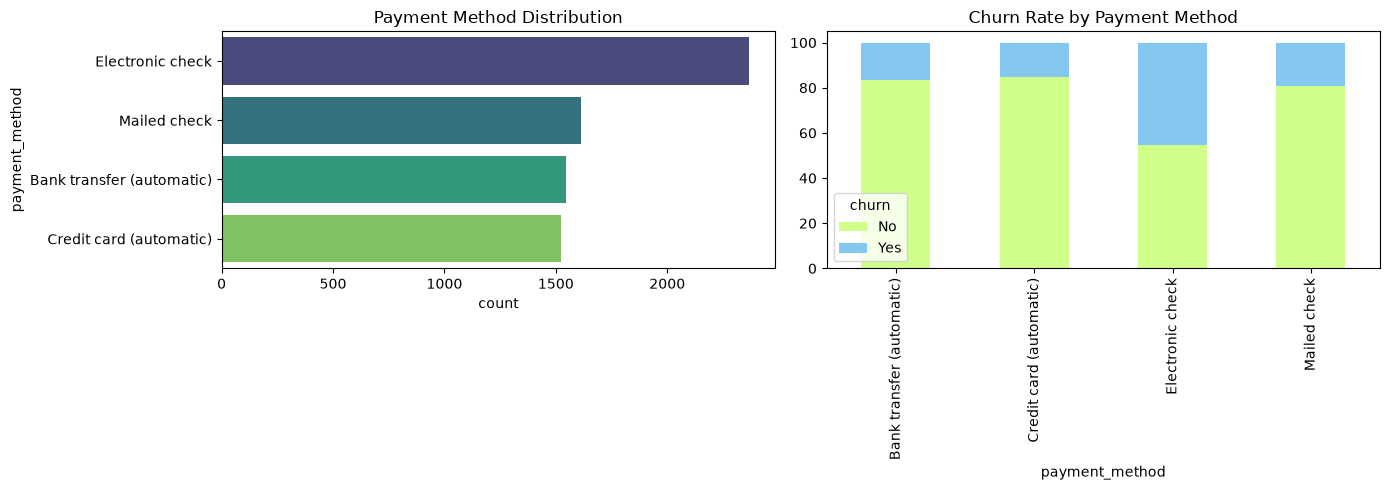

TECH_SUPPORT


,Customers
tech_support,
No,3473
Yes,2044
No internet service,1526


churn,No,Yes
tech_support,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


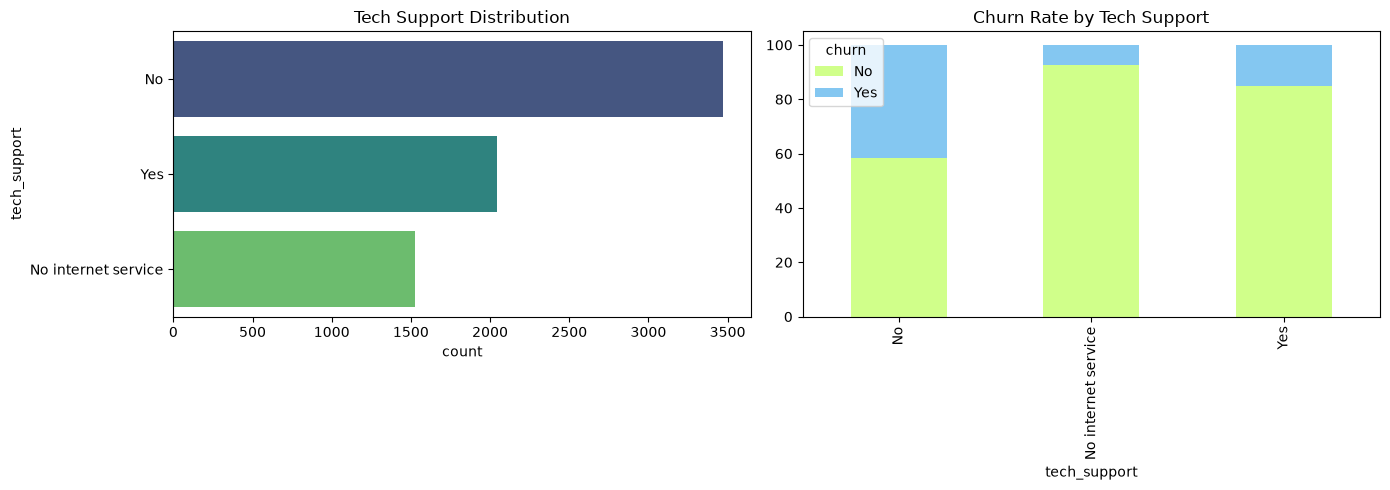

ONLINE_SECURITY


,Customers
online_security,
No,3498
Yes,2019
No internet service,1526


churn,No,Yes
online_security,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


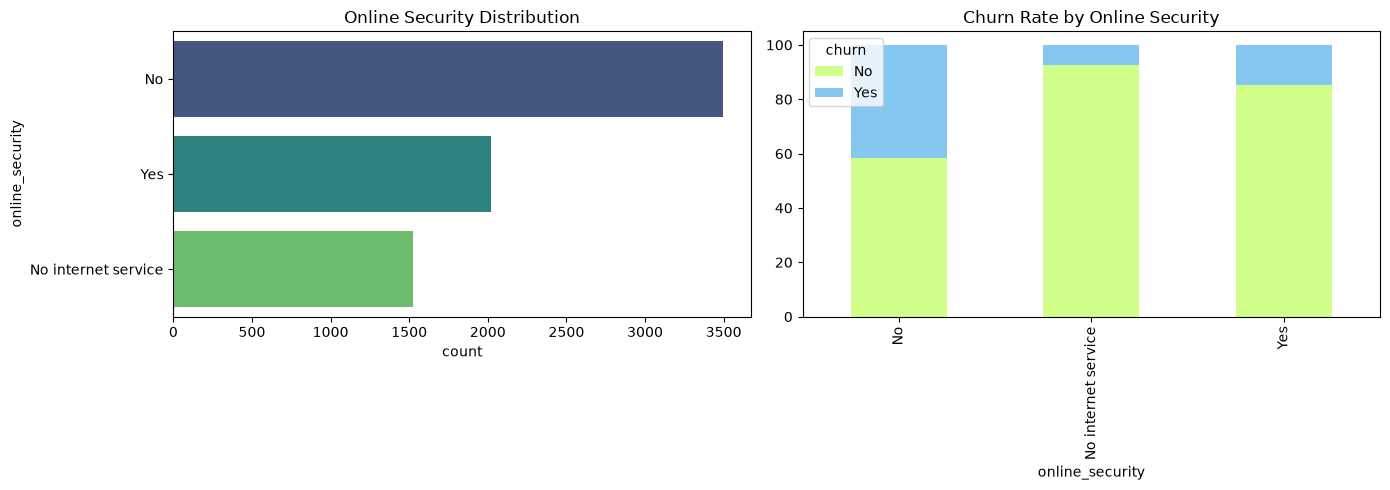

ONLINE_BACKUP


,Customers
online_backup,
No,3088
Yes,2429
No internet service,1526


churn,No,Yes
online_backup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


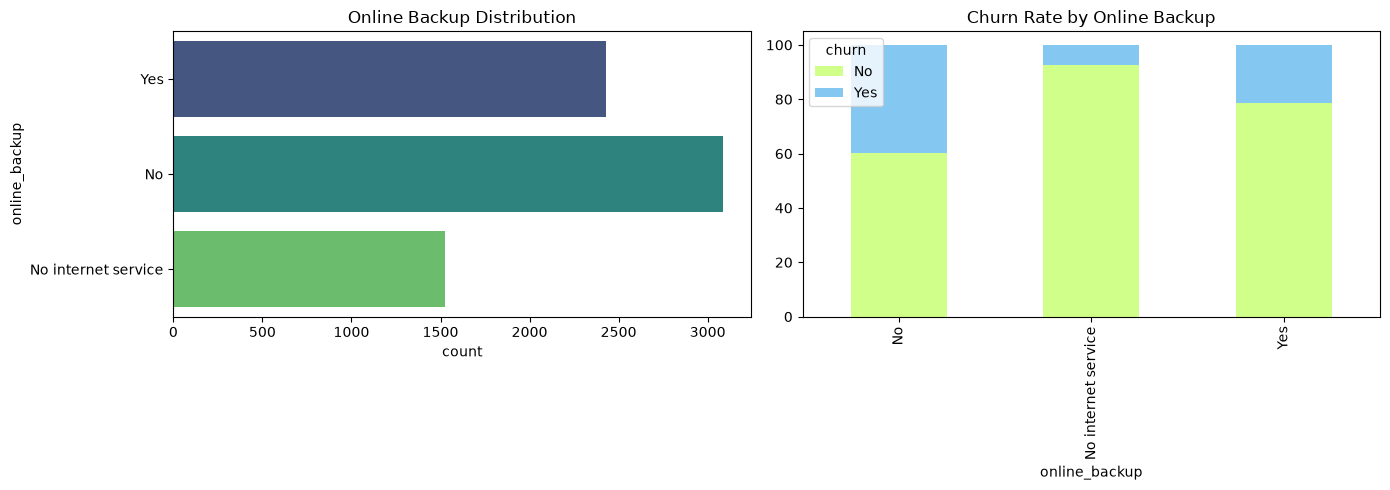

DEVICE_PROTECTION


,Customers
device_protection,
No,3095
Yes,2422
No internet service,1526


churn,No,Yes
device_protection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


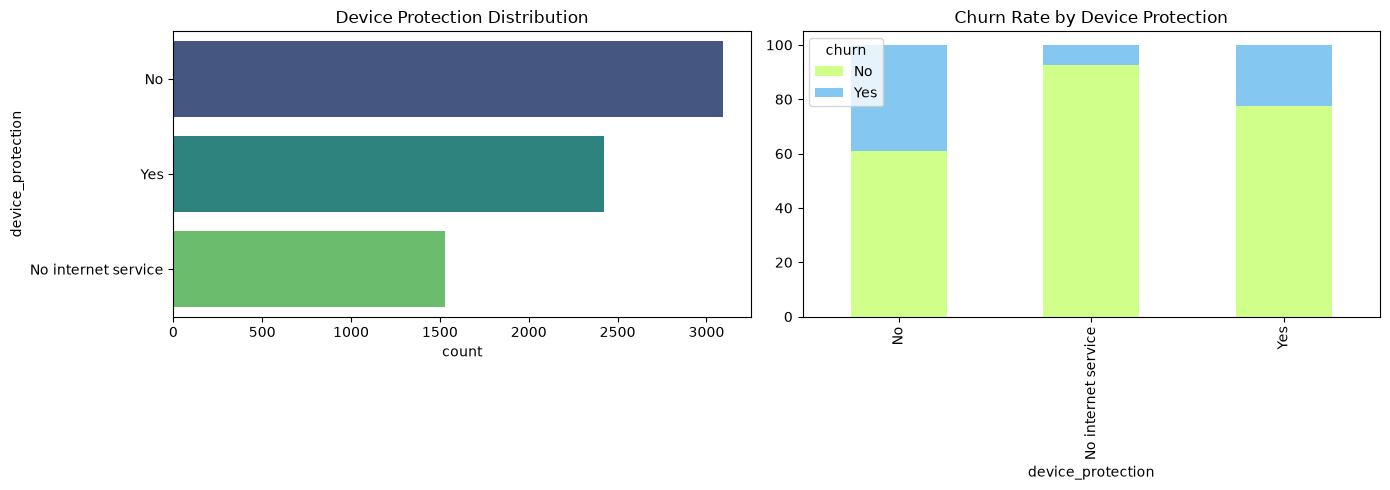

STREAMING_TV


,Customers
streaming_tv,
No,2810
Yes,2707
No internet service,1526


churn,No,Yes
streaming_tv,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


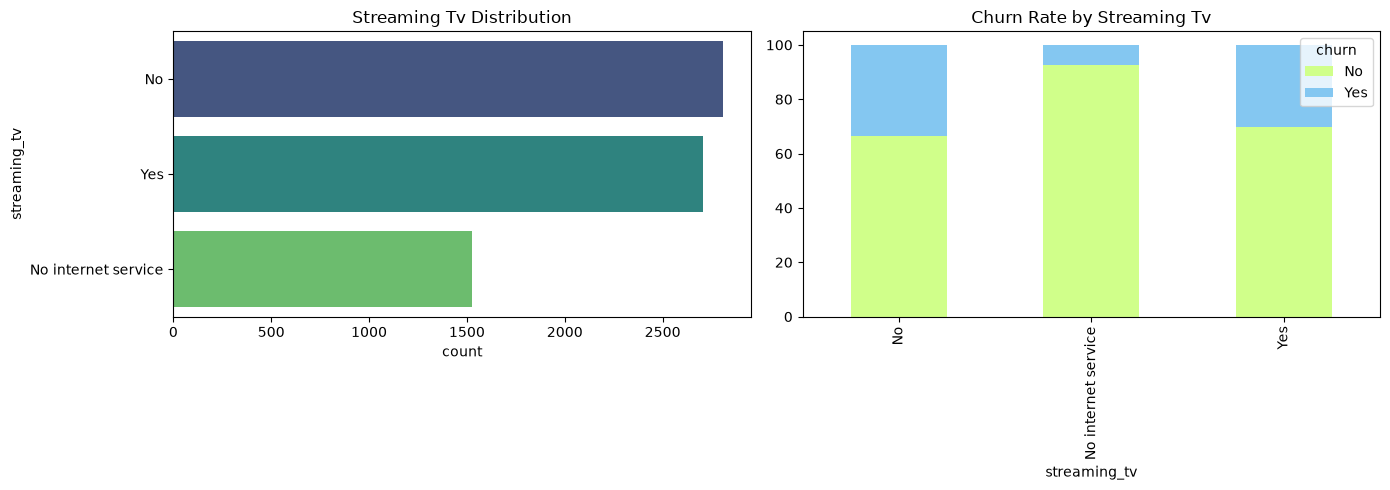

STREAMING_MOVIES


,Customers
streaming_movies,
No,2785
Yes,2732
No internet service,1526


churn,No,Yes
streaming_movies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


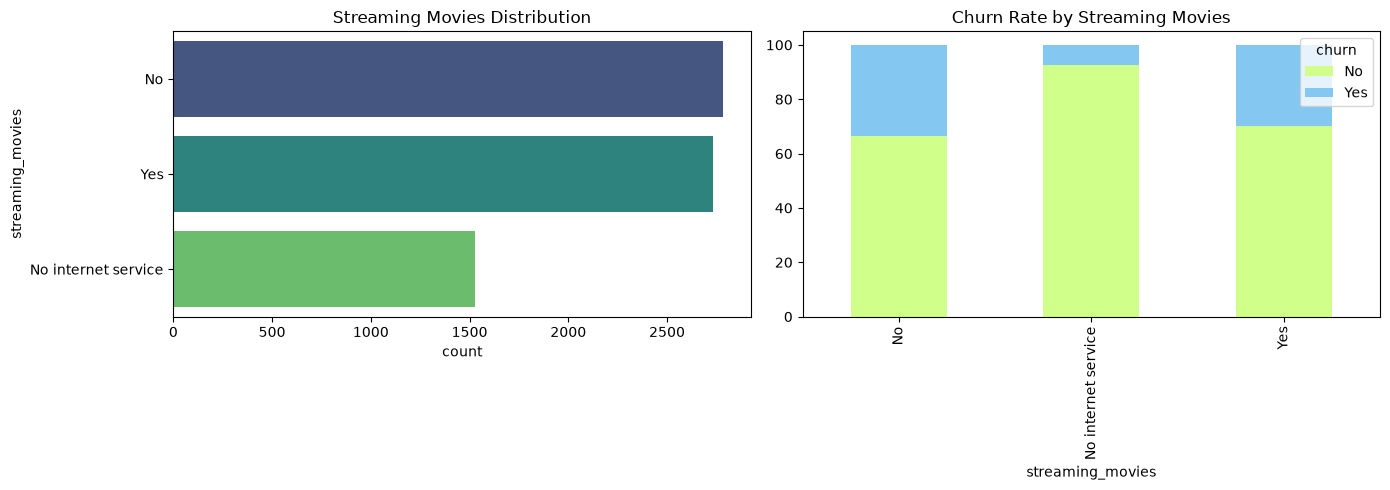

PAPERLESS_BILLING


,Customers
paperless_billing,
Yes,4171
No,2872


churn,No,Yes
paperless_billing,,
No,83.67,16.33
Yes,66.43,33.57


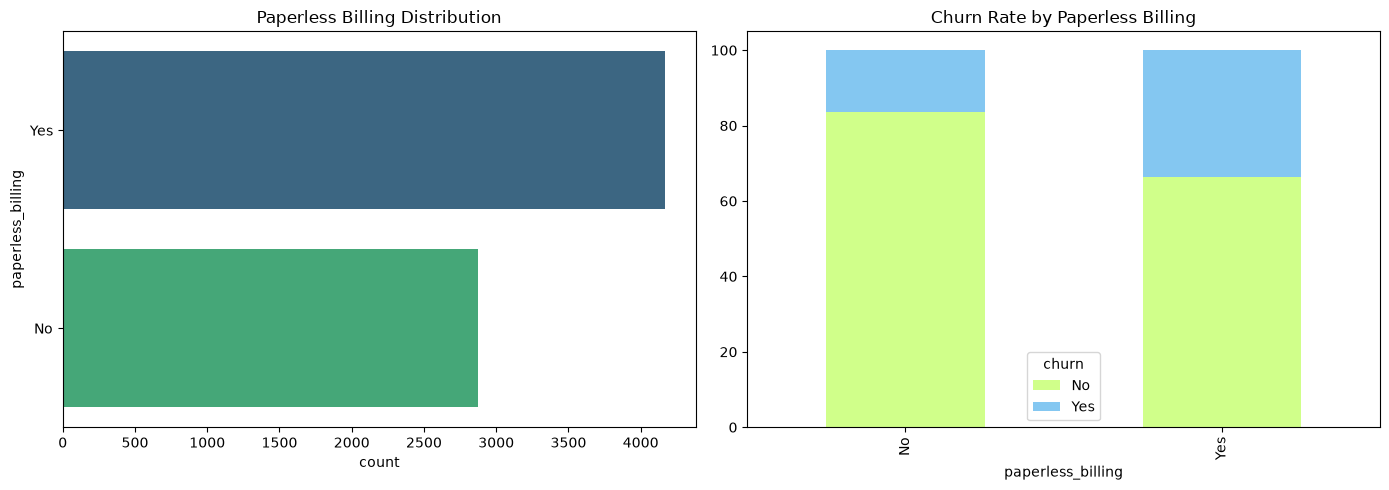

PARTNER


,Customers
partner,
No,3641
Yes,3402


churn,No,Yes
partner,,
No,67.04,32.96
Yes,80.34,19.66


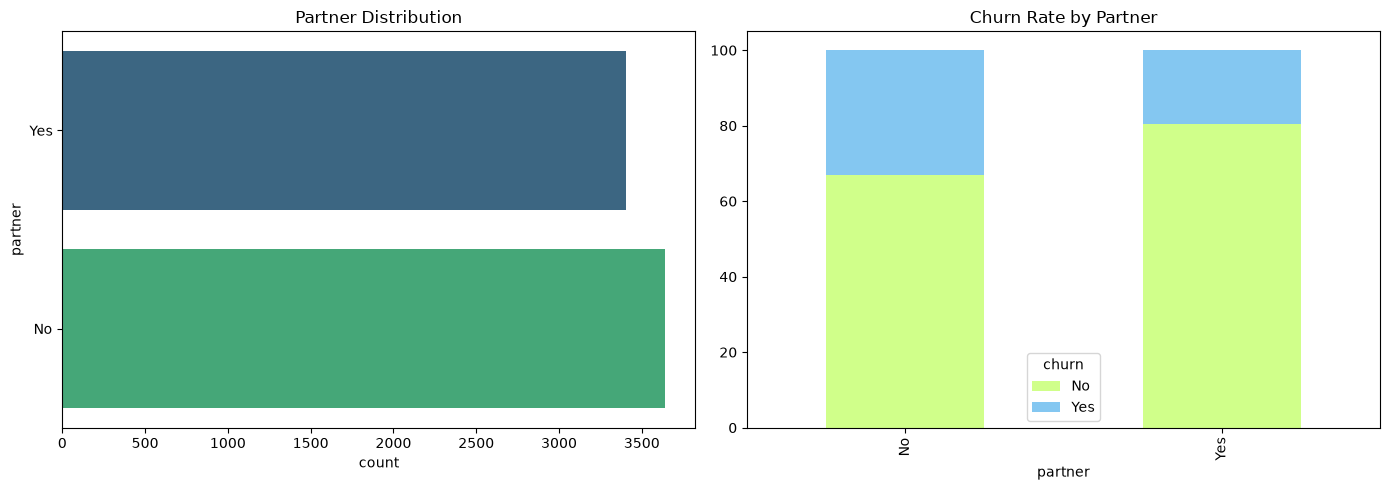

DEPENDENTS


,Customers
dependents,
No,4933
Yes,2110


churn,No,Yes
dependents,,
No,68.72,31.28
Yes,84.55,15.45


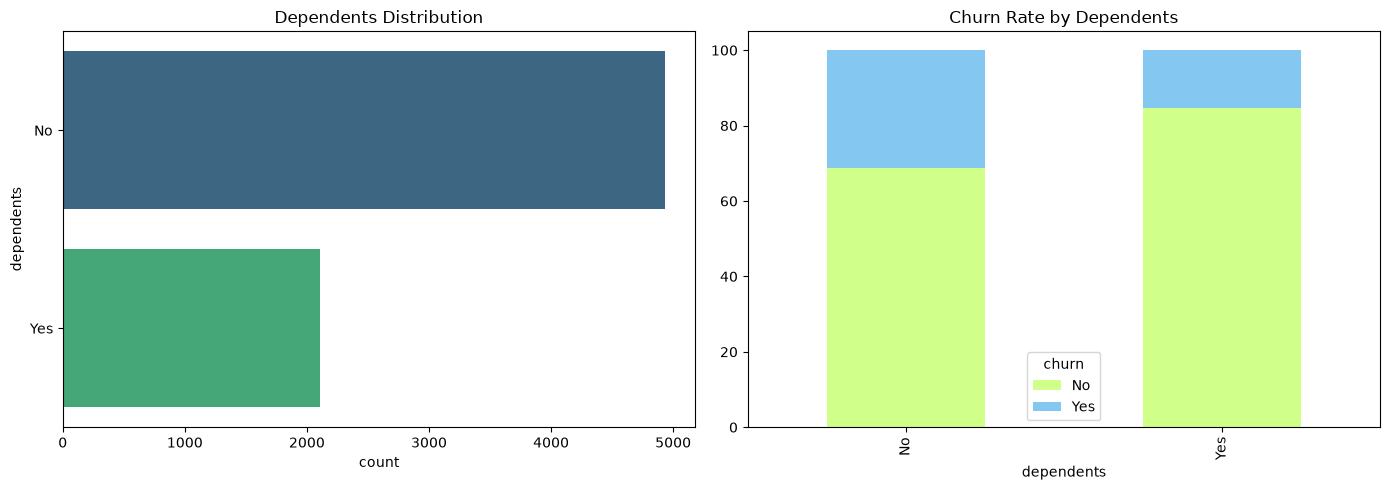

SENIOR_CITIZEN


,Customers
senior_citizen,
No,5901
Yes,1142


churn,No,Yes
senior_citizen,,
No,76.39,23.61
Yes,58.32,41.68


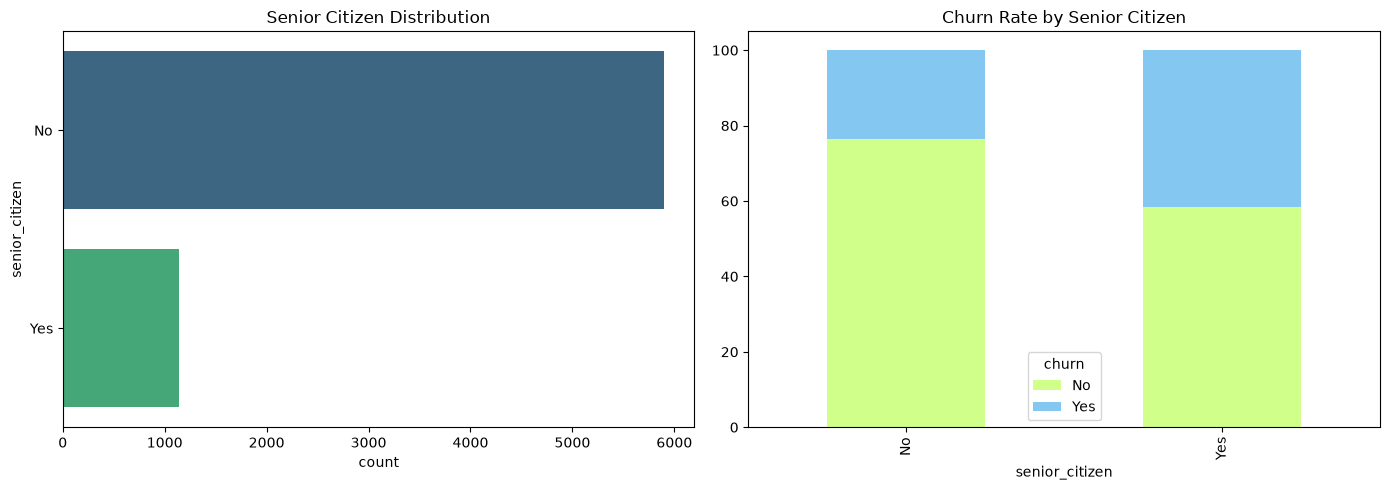

In [31]:
for feature in categorical_features:
    analyze_categorical_feature(df, feature)

CONTRACT


,Customers
contract,
Month-to-month,3875
Two year,1695
One year,1473


churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


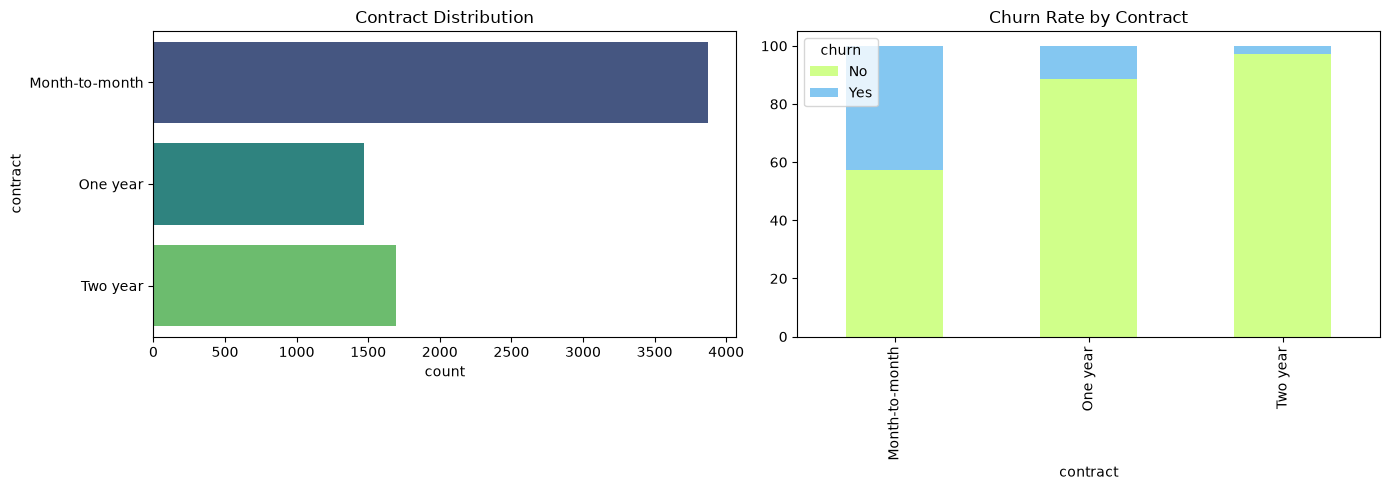

INTERNET_SERVICE


,Customers
internet_service,
Fiber optic,3096
DSL,2421
No,1526


churn,No,Yes
internet_service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


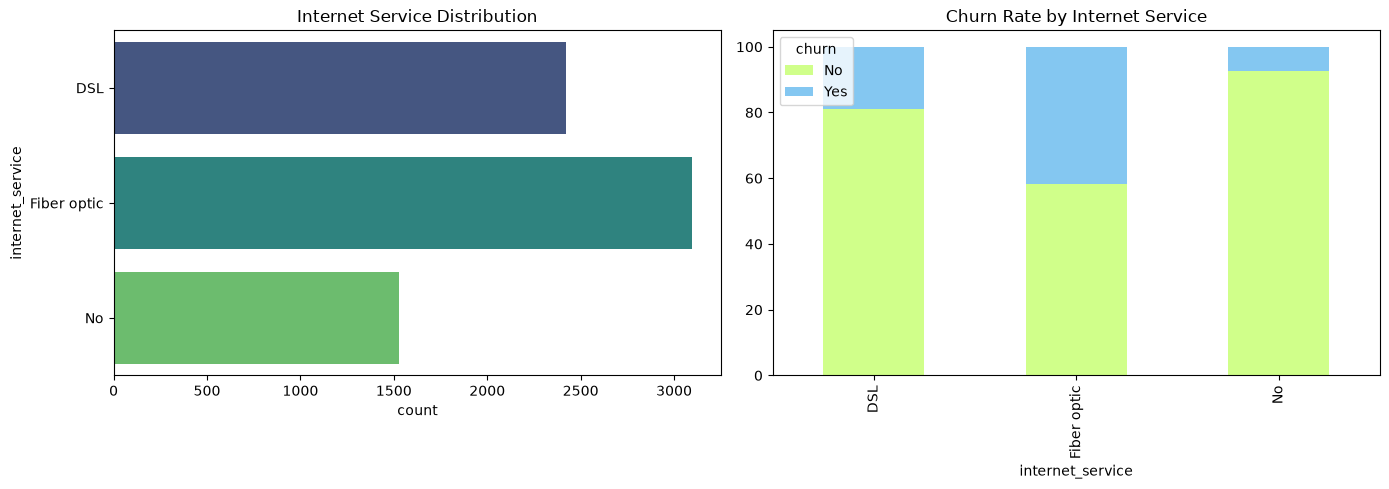

PAYMENT_METHOD


,Customers
payment_method,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


churn,No,Yes
payment_method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


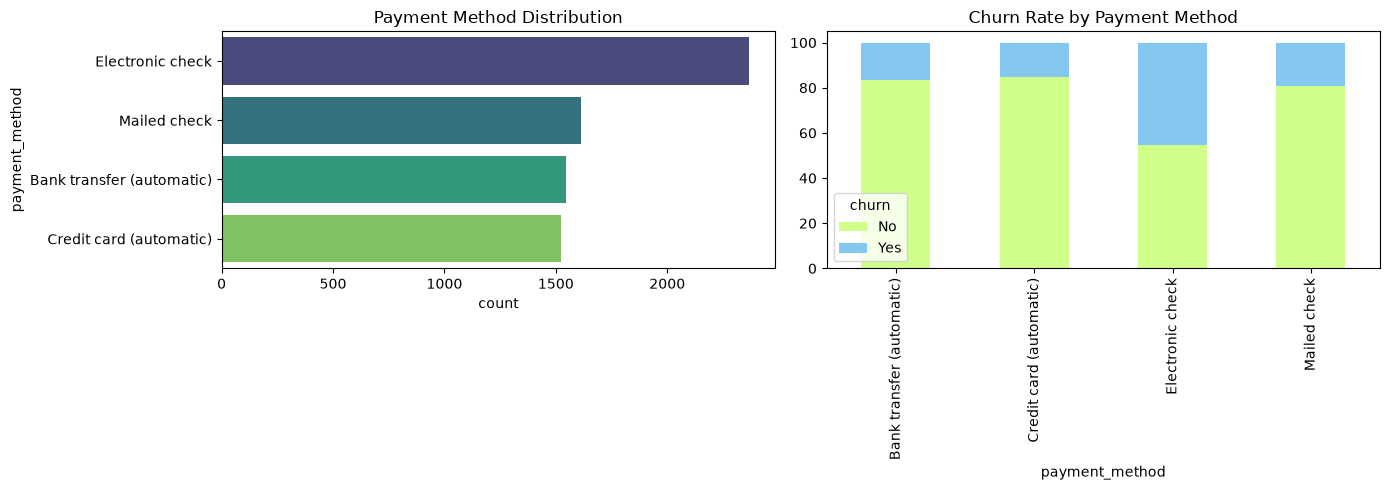

TECH_SUPPORT


,Customers
tech_support,
No,3473
Yes,2044
No internet service,1526


churn,No,Yes
tech_support,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


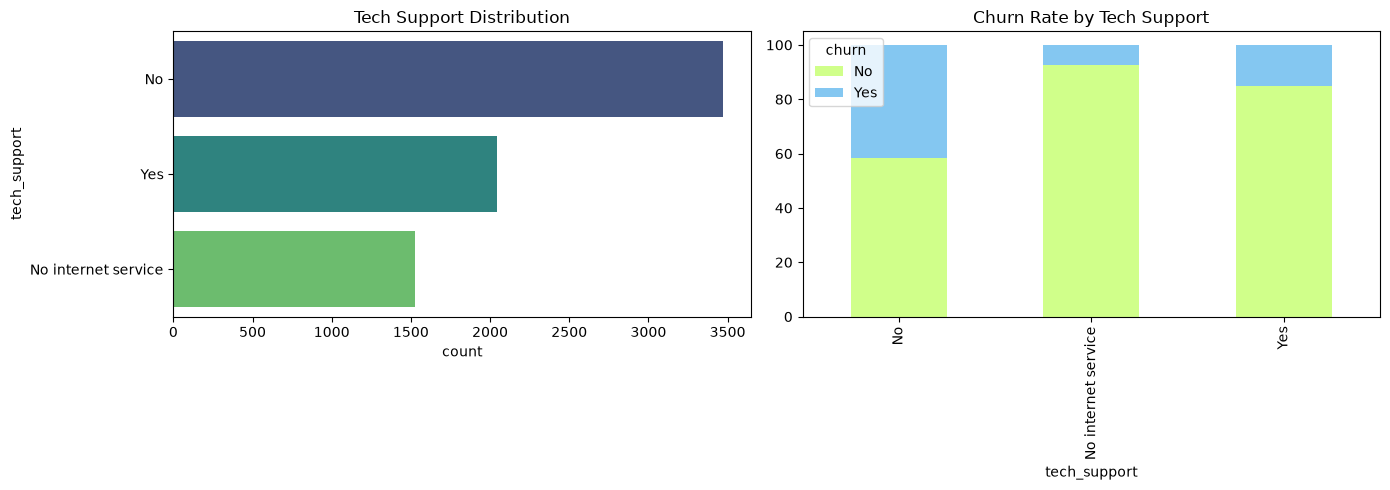

ONLINE_SECURITY


,Customers
online_security,
No,3498
Yes,2019
No internet service,1526


churn,No,Yes
online_security,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


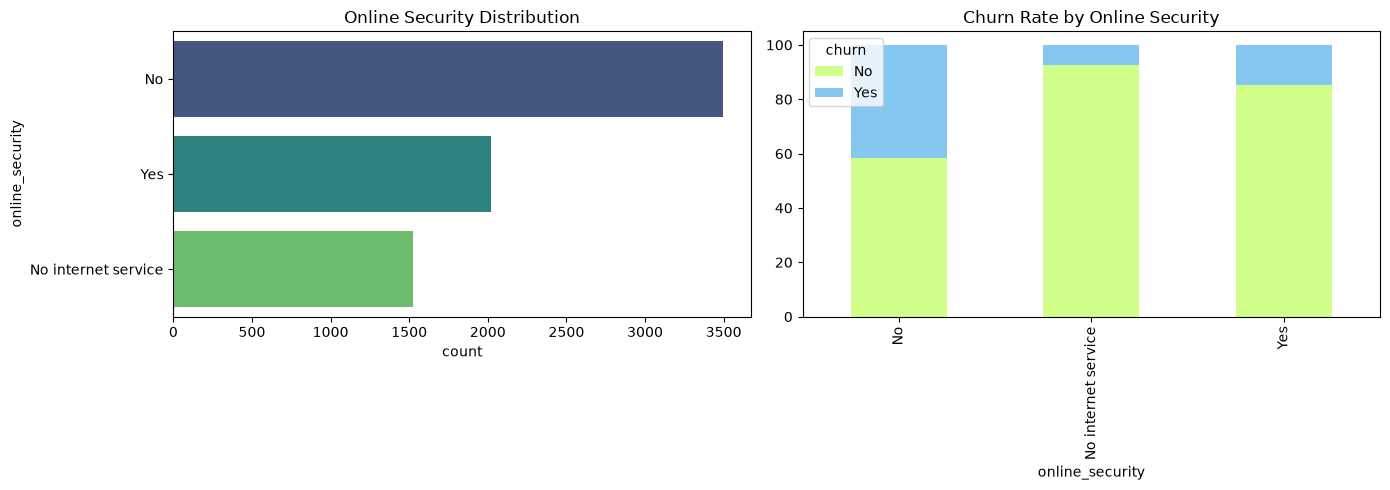

ONLINE_BACKUP


,Customers
online_backup,
No,3088
Yes,2429
No internet service,1526


churn,No,Yes
online_backup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


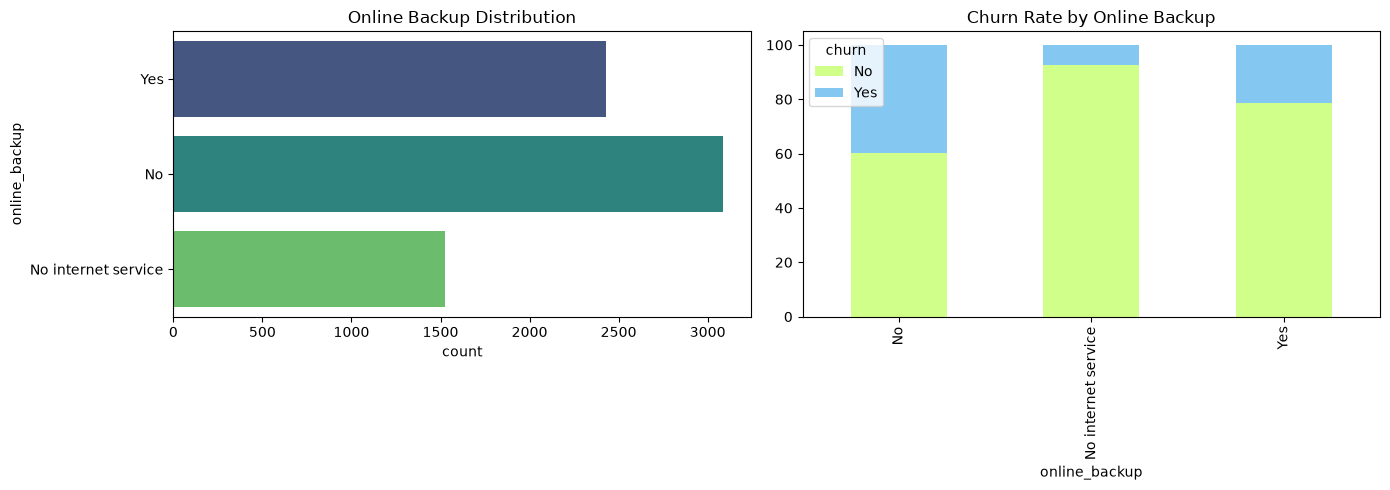

DEVICE_PROTECTION


,Customers
device_protection,
No,3095
Yes,2422
No internet service,1526


churn,No,Yes
device_protection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


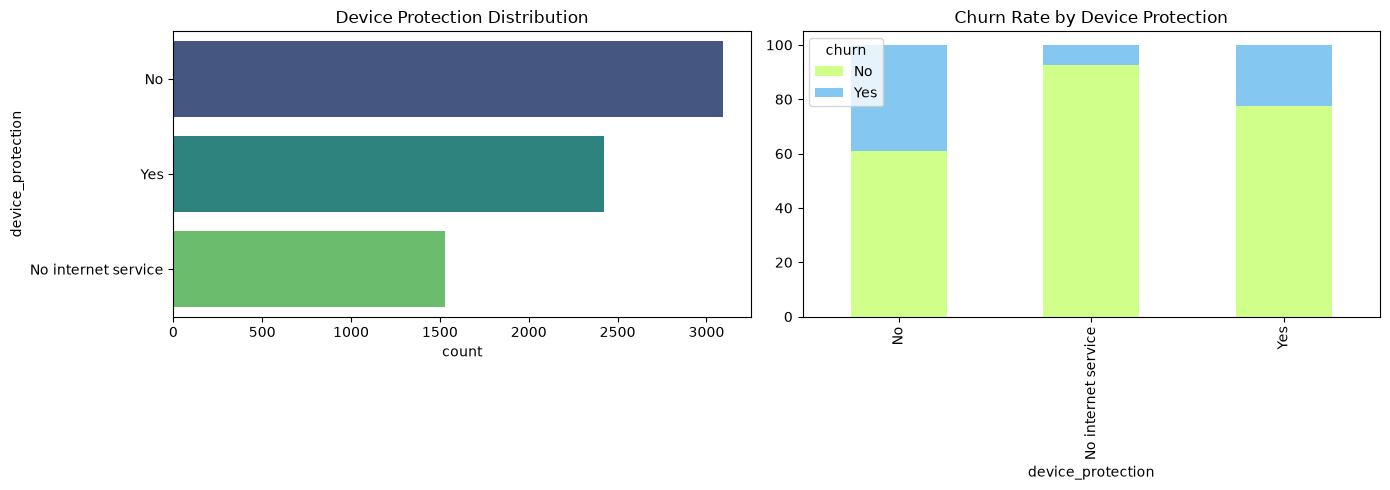

STREAMING_TV


,Customers
streaming_tv,
No,2810
Yes,2707
No internet service,1526


churn,No,Yes
streaming_tv,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


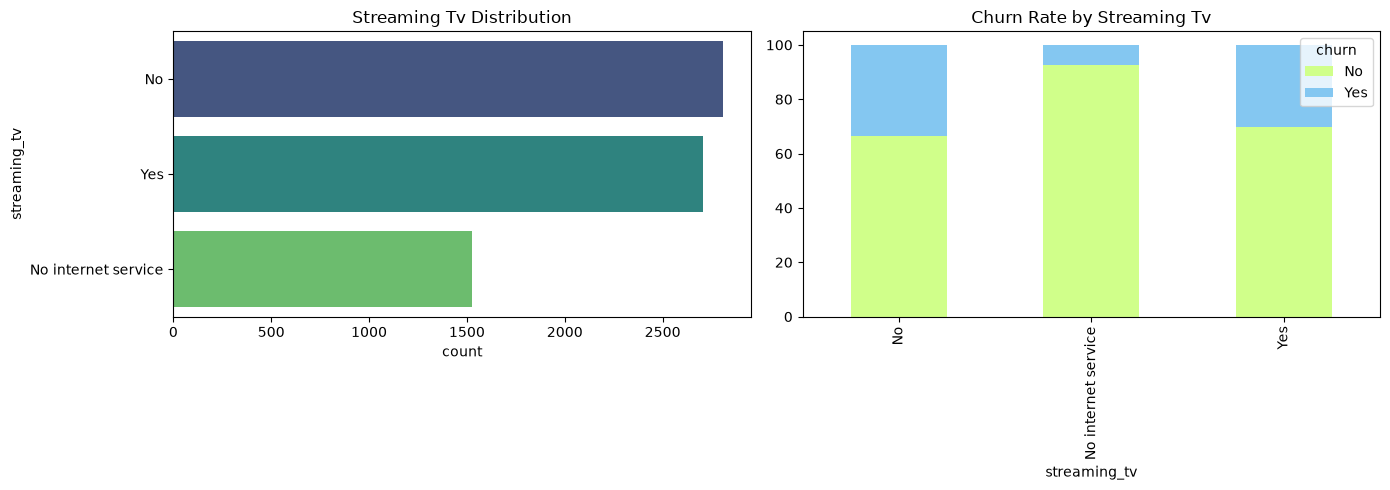

STREAMING_MOVIES


,Customers
streaming_movies,
No,2785
Yes,2732
No internet service,1526


churn,No,Yes
streaming_movies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


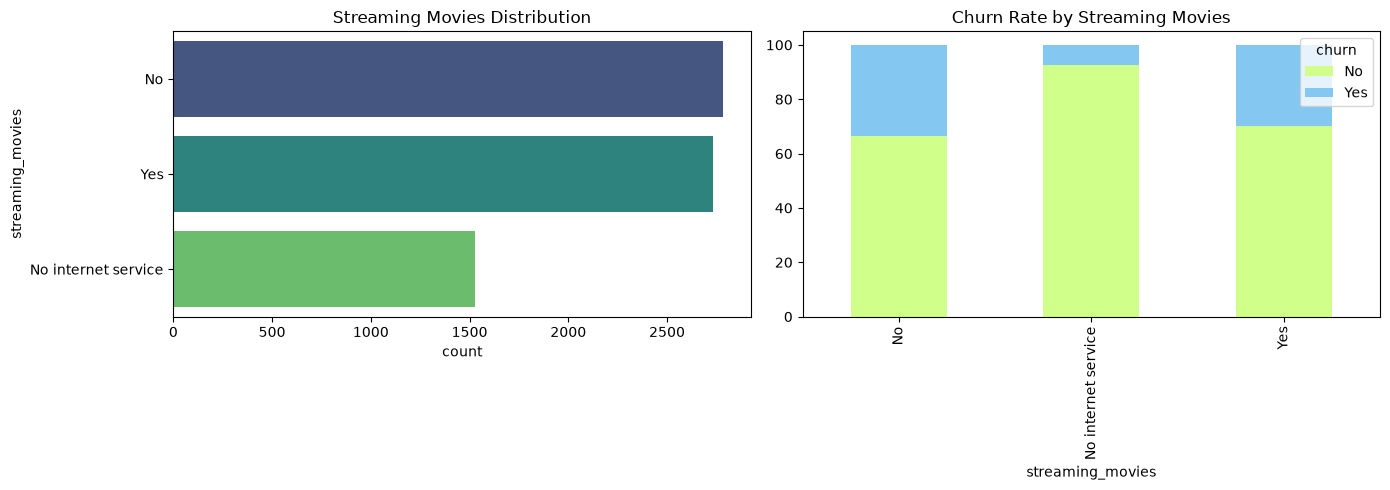

PAPERLESS_BILLING


,Customers
paperless_billing,
Yes,4171
No,2872


churn,No,Yes
paperless_billing,,
No,83.67,16.33
Yes,66.43,33.57


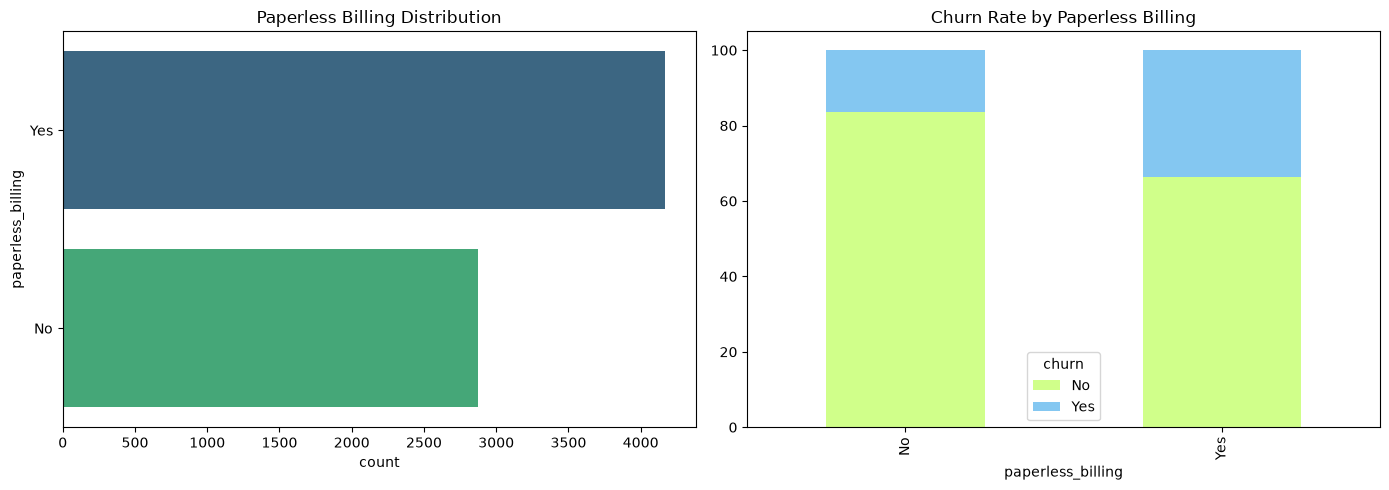

PARTNER


,Customers
partner,
No,3641
Yes,3402


churn,No,Yes
partner,,
No,67.04,32.96
Yes,80.34,19.66


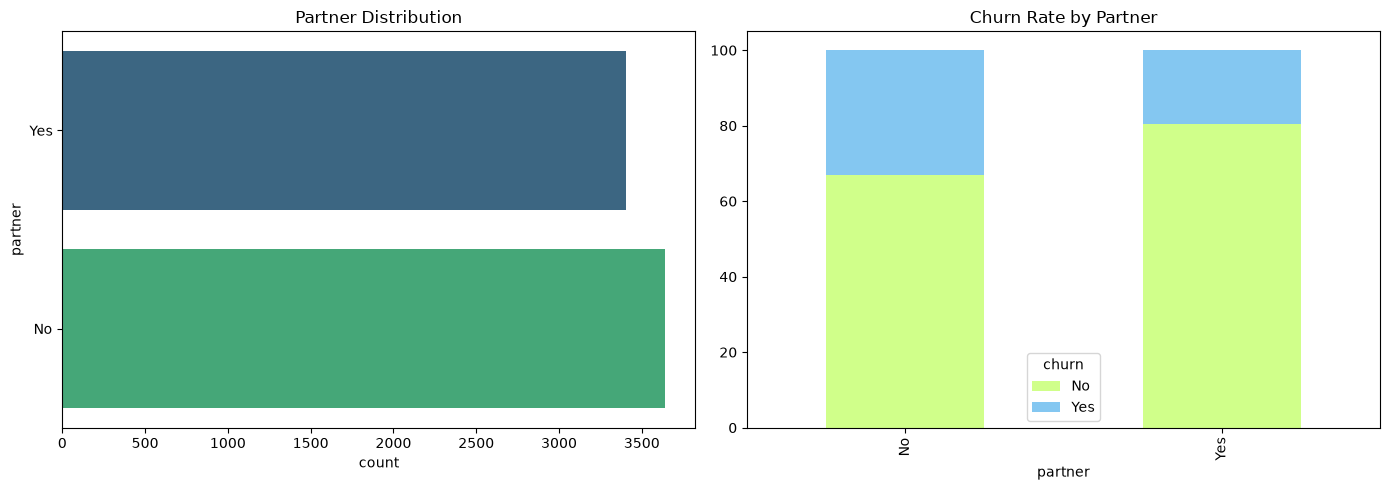

DEPENDENTS


,Customers
dependents,
No,4933
Yes,2110


churn,No,Yes
dependents,,
No,68.72,31.28
Yes,84.55,15.45


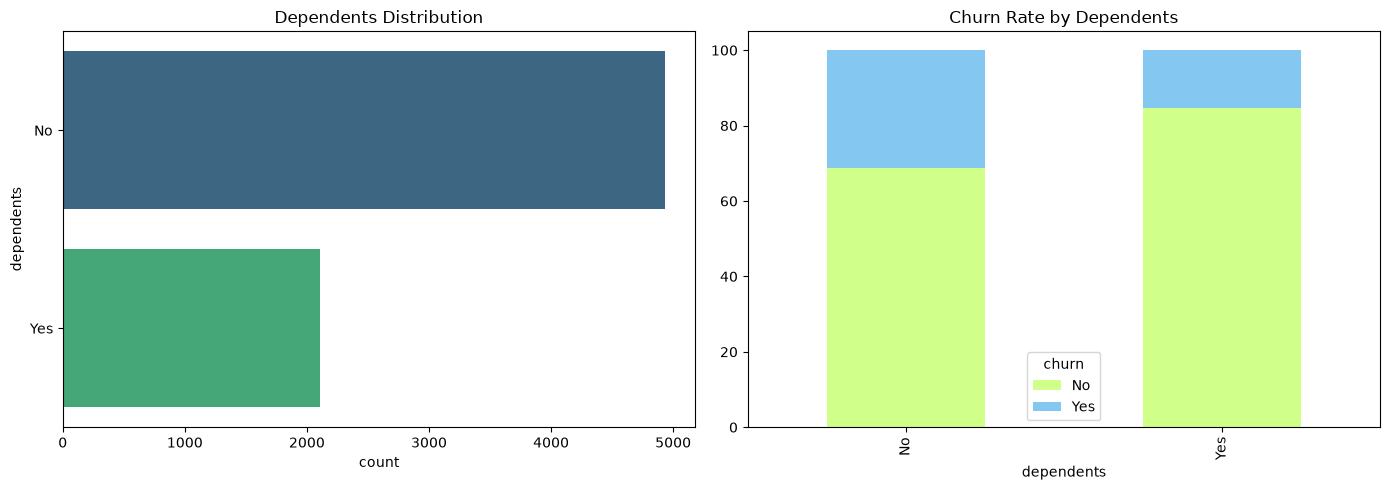

SENIOR_CITIZEN


,Customers
senior_citizen,
No,5901
Yes,1142


churn,No,Yes
senior_citizen,,
No,76.39,23.61
Yes,58.32,41.68


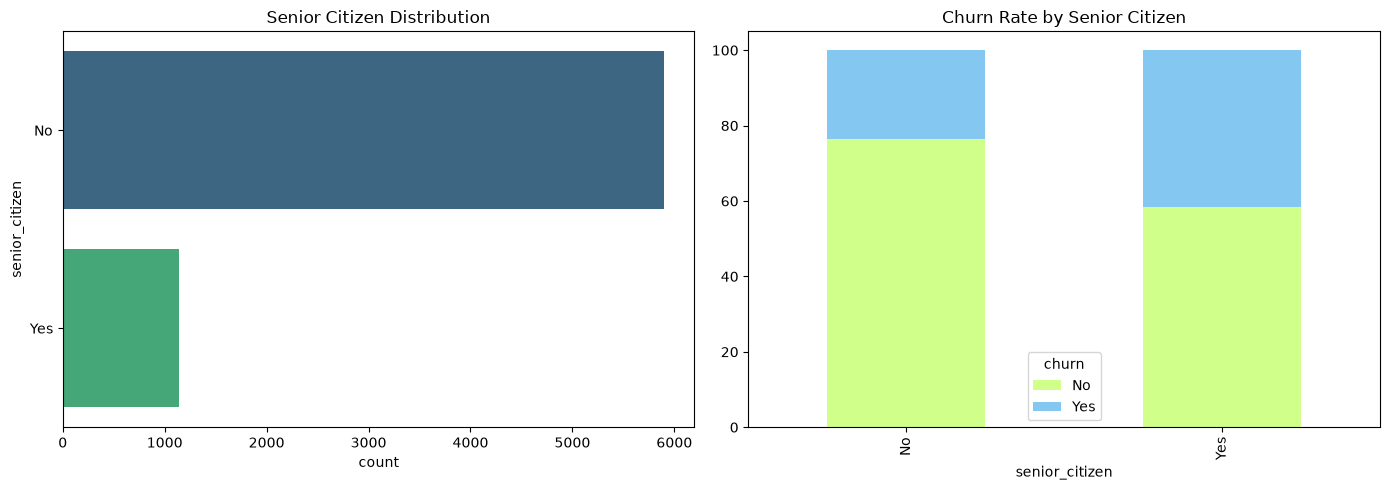

In [32]:
for feature in categorical_features:
    analyze_categorical_feature(df, feature)

In [33]:
summary = pd.DataFrame({

    "Feature":[
        "Contract",
        "Internet Service",
        "Payment Method",
        "Tech Support",
        "Online Security",
        "Tenure",
        "Monthly Charges"
    ],

    "Relationship with Churn":[

        "Very Strong",

        "Strong",

        "Moderate",

        "Strong",

        "Strong",

        "Very Strong",

        "Moderate"

    ],

    "Business Interpretation":[

        "Month-to-month customers churn much more frequently.",

        "Fiber optic customers exhibit higher churn.",

        "Electronic check customers churn more often.",

        "Customers without tech support leave more frequently.",

        "Customers without online security are more likely to churn.",

        "Customers with shorter tenure churn much more frequently.",

        "Higher monthly charges are associated with increased churn."

    ]

})

summary

,Feature,Relationship with Churn,Business Interpretation
0,Contract,Very Strong,Month-to-month customers churn much more frequ...
1,Internet Service,Strong,Fiber optic customers exhibit higher churn.
2,Payment Method,Moderate,Electronic check customers churn more often.
3,Tech Support,Strong,Customers without tech support leave more freq...
4,Online Security,Strong,Customers without online security are more lik...
5,Tenure,Very Strong,Customers with shorter tenure churn much more ...
6,Monthly Charges,Moderate,Higher monthly charges are associated with inc...


## Main Findings

The exploratory analysis identified several important patterns associated with customer churn.

Contract type and customer tenure showed the strongest relationships with churn. Customers with month-to-month contracts and shorter tenure were substantially more likely to leave the company.

Customers using fiber optic internet and electronic check payments also exhibited higher churn rates.

Additional services such as technical support and online security were associated with improved customer retention.

Monthly charges also appeared to influence churn, as customers who left the company generally had higher monthly costs.

## High-Risk Customer Profile

Based on the exploratory analysis, a customer with a higher risk of churn typically has the following characteristics:

- Month-to-month contract
- Short customer tenure
- Fiber optic internet service
- Electronic check payment method
- No technical support
- No online security
- Relatively high monthly charges

This customer profile can help the company prioritize retention strategies and targeted interventions.